# 07 · Wrap-Up & Cheat-Sheet — *Which Autoencoder for Which Problem?*

This final notebook has no training. It is the **interview map**: it consolidates the whole series
into decision guides, comparison tables, the key equations, and crisp answers to the questions you
are most likely to be asked. Skim it the morning of your interview.

**The through-line of the series**

> Every autoencoder is the *same* skeleton — **encoder → code → decoder**, trained to reconstruct.
> You get different capabilities by turning **three knobs**: the **bottleneck**, the **loss/regularizer**,
> and **what you feed in vs. ask out**.


## 1. One architecture, three knobs

```
                          ┌────────────────── THE AUTOENCODER ──────────────────┐
                          │                                                     │
        x ───────────────▶│   ENCODER  f  ──▶   code z   ──▶   DECODER  g   ─────┼──▶  x̂
                          │                                                     │
                          └─────────────────────────────────────────────────────┘
                                            │
       ┌────────────────────────────────────┼────────────────────────────────────┐
       ▼                                    ▼                                     ▼
  KNOB 1: the CODE                    KNOB 2: the LOSS                    KNOB 3: in vs out
  • small  → undercomplete            • +L1(z)  → sparse                  • x̃(noisy)→x → denoising
    (compress)                        • +‖∂z/∂x‖→ contractive             • mask→full → inpainting
  • large + reg → overcomplete        • +KL(z‖N(0,1)) → VAE (generate)    • seq→seq → sequence AE
                                       • MSE/BCE → plain reconstruction    • x→x → vanilla
```

Turn a knob, get a new tool. That's the entire zoo.


## 2. The autoencoder zoo — at a glance

| Type | The knob it turns | What it forces | Primary use | Notebook |
|---|---|---|---|---|
| **Undercomplete AE** | small code | compression onto a manifold | dimensionality reduction, visualization | 01 |
| **(Linear AE)** | small code, no activations | = **PCA** | baseline / intuition | 01 |
| **Denoising AE (DAE)** | corrupt the input | model the data manifold (no identity cheat) | cleaning signals/images, robust features, imputation | 02 |
| **Convolutional AE** | conv encoder/decoder | spatial, translation-invariant features | images (denoise, inpaint, compress) | 02 |
| **Sparse AE** | +L1/KL on activations | few active units → interpretable parts | feature learning, interpretability | 04 |
| **Contractive AE** | +Jacobian penalty | code insensitive to input wiggles | robust representations | 04 |
| **Variational AE (VAE)** | +KL to N(0,I) + sampling | a smooth, sampleable latent | **generation**, interpolation, latent modeling | 05 |
| **Sequence / LSTM AE** | recurrent encoder/decoder | temporal dynamics of a window | time-series & sensor anomaly detection | 06 |


## 3. Decision guide — pick the AE from the problem

Read top-down: start from what you actually need out of the model.


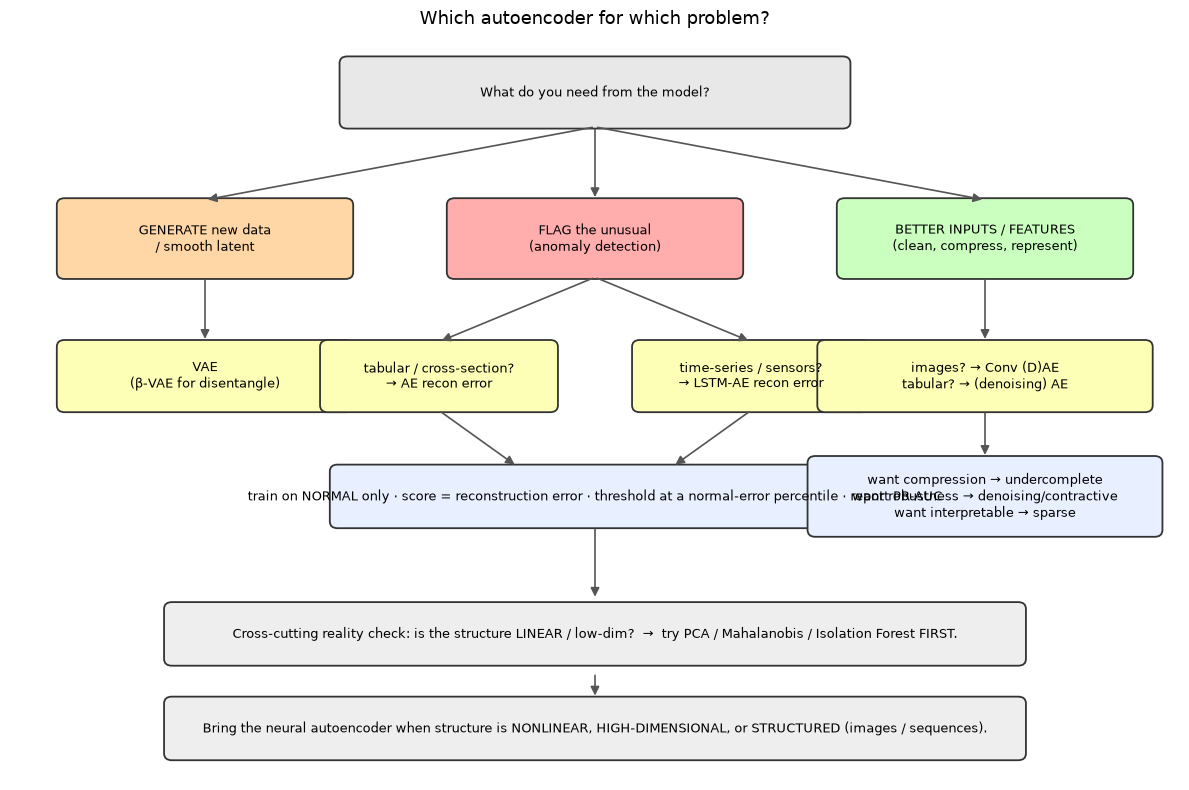

In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

def box(ax, xy, w, h, text, fc):
    ax.add_patch(FancyBboxPatch((xy[0]-w/2, xy[1]-h/2), w, h,
                 boxstyle="round,pad=0.02,rounding_size=0.08", fc=fc, ec="#333", lw=1.3))
    ax.text(xy[0], xy[1], text, ha="center", va="center", fontsize=9)

def arrow(ax, a, b, label=""):
    ax.add_patch(FancyArrowPatch(a, b, arrowstyle="-|>", mutation_scale=13, lw=1.2, color="#555"))
    if label:
        ax.text((a[0]+b[0])/2, (a[1]+b[1])/2+0.12, label, ha="center", fontsize=8, color="#b30000")

fig, ax = plt.subplots(figsize=(12, 8))
box(ax, (6, 9.3), 5.2, 0.8, "What do you need from the model?", "#e8e8e8")

# level 1 branches
box(ax, (2, 7.6), 3.0, 0.9, "GENERATE new data\n/ smooth latent", "#ffd6a5")
box(ax, (6, 7.6), 3.0, 0.9, "FLAG the unusual\n(anomaly detection)", "#ffadad")
box(ax, (10, 7.6), 3.0, 0.9, "BETTER INPUTS / FEATURES\n(clean, compress, represent)", "#caffbf")
for x in (2, 6, 10):
    arrow(ax, (6, 8.9), (x, 8.05))

# generate branch
box(ax, (2, 6.0), 3.0, 0.8, "VAE\n(β-VAE for disentangle)", "#fdffb6")
arrow(ax, (2, 7.15), (2, 6.4))

# anomaly branch
box(ax, (4.4, 6.0), 2.4, 0.8, "tabular / cross-section?\n→ AE recon error", "#fdffb6")
box(ax, (7.6, 6.0), 2.4, 0.8, "time-series / sensors?\n→ LSTM-AE recon error", "#fdffb6")
arrow(ax, (6, 7.15), (4.4, 6.4)); arrow(ax, (6, 7.15), (7.6, 6.4))
box(ax, (6, 4.6), 5.4, 0.7, "train on NORMAL only · score = reconstruction error · threshold at a normal-error percentile · report PR-AUC", "#e8f0ff")
arrow(ax, (4.4, 5.6), (5.2, 4.95)); arrow(ax, (7.6, 5.6), (6.8, 4.95))

# features branch
box(ax, (10, 6.0), 3.4, 0.8, "images? → Conv (D)AE\ntabular? → (denoising) AE", "#fdffb6")
arrow(ax, (10, 7.15), (10, 6.4))
box(ax, (10, 4.6), 3.6, 0.9, "want compression → undercomplete\nwant robustness → denoising/contractive\nwant interpretable → sparse", "#e8f0ff")
arrow(ax, (10, 5.6), (10, 5.05))

# footer note
box(ax, (6, 3.0), 8.8, 0.7, "Cross-cutting reality check: is the structure LINEAR / low-dim?  →  try PCA / Mahalanobis / Isolation Forest FIRST.", "#eeeeee")
box(ax, (6, 1.9), 8.8, 0.7, "Bring the neural autoencoder when structure is NONLINEAR, HIGH-DIMENSIONAL, or STRUCTURED (images / sequences).", "#eeeeee")
arrow(ax, (6, 4.25), (6, 3.4)); arrow(ax, (6, 2.55), (6, 2.25))

ax.set_xlim(0, 12); ax.set_ylim(1.3, 10); ax.axis("off")
ax.set_title("Which autoencoder for which problem?", fontsize=13)
plt.tight_layout(); plt.show()


## 4. Consulting problem → autoencoder solution

| Business problem | Autoencoder solution | Why it fits | Watch out for |
|---|---|---|---|
| **Card fraud / intrusion / fault detection** | AE (or LSTM-AE) trained on normal, error as score | rare, unlabeled, evolving anomalies — no need for anomaly labels | PR-AUC not just ROC; contamination; threshold drift |
| **Predictive maintenance from sensors** | **LSTM-AE** on windows; per-timestep error | captures temporal dynamics; localizes the fault in time | window size; streaming thresholds |
| **Cleaning scans / signals / images** | **Denoising AE** (conv for images) | learns the clean-data manifold, projects noise out | must model the corruption you'll actually face |
| **Missing-data imputation** | Denoising AE with **masking** | masking = missingness; reconstruct the hidden entries | MAR/MNAR assumptions |
| **Dimensionality reduction / visualization** | **Undercomplete AE** (or PCA if linear) | compact nonlinear code; 2-D map for free | linear? PCA is simpler & closed-form |
| **Few labels, lots of unlabeled data** | AE/denoising pretrain → small supervised head | learn features unsupervised, fine-tune cheaply | reconstruction ≠ discrimination; prefer SSL if you can |
| **Data augmentation / synthetic samples** | **VAE** sample & decode | smooth latent generates plausible variants | blurry vs GAN/diffusion |
| **Recommendations (implicit feedback)** | AE over the user–item vector (e.g. **AutoRec**) | reconstruct a user's interactions → predict the blanks | sparsity, cold start |


## 5. The equations, on one page

Let $x$ be the input, $z=f(x)$ the code, $\hat{x}=g(z)$ the reconstruction.

| Model | Loss (minimize) |
|---|---|
| **Plain AE** | $\lVert x-\hat{x}\rVert^2$ |
| **Denoising AE** | $\lVert x-g(f(\tilde{x}))\rVert^2$, with $\tilde{x}=x+\text{noise}$ |
| **Sparse AE** | $\lVert x-\hat{x}\rVert^2 + \lambda\lVert z\rVert_1$  (or $+\lambda\sum_j \mathrm{KL}(\rho\Vert\hat{\rho}_j)$) |
| **Contractive AE** | $\lVert x-\hat{x}\rVert^2 + \lambda\big\lVert \partial z/\partial x\big\rVert_F^2$ |
| **VAE** | $\underbrace{\mathbb{E}[-\log p(x\mid z)]}_{\text{recon (BCE/MSE)}} + \underbrace{D_{\mathrm{KL}}(q(z\mid x)\Vert \mathcal{N}(0,I))}_{-\tfrac12\sum(1+\log\sigma^2-\mu^2-\sigma^2)}$ |

**Reparameterization (VAE):** $z=\mu(x)+\sigma(x)\odot\varepsilon,\ \varepsilon\sim\mathcal{N}(0,I)$ — lets gradients flow through the sampling step.

**Anomaly score (any AE):** $\text{score}(x)=\lVert x-\hat{x}\rVert^2$; flag if $>\tau$, with $\tau$ a high percentile of normal-data errors.


## 6. The questions you'll be asked (with crisp answers)

**Fundamentals**
- *What is an autoencoder?* A net trained to reconstruct its input through a bottleneck; the code is a
  learned, compressed summary. Self-supervised — no labels.
- *Why the bottleneck?* It blocks the identity shortcut and forces the model to keep only essential
  structure. Too wide (overcomplete) with no regularization → it can just copy and learns nothing.
- *AE vs PCA?* A **linear** AE with MSE = PCA (same subspace). A **nonlinear** AE generalizes PCA to
  curved manifolds → better compression, but non-convex and less interpretable. Wins most at **high
  compression**; PCA can match/beat it when the code is wide (its closed-form is easier to optimize).

**Regularized AEs**
- *Sparse vs contractive vs denoising?* Sparse = *few units fire* (L1/KL on activations). Contractive =
  *code barely moves* under input change (Jacobian penalty). Denoising = robustness *implicitly*, by
  corrupting the input. All say "ignore unimportant directions."

**VAE**
- *Why can a VAE generate but a plain AE can't?* Plain-AE latent has holes and unknown shape → random
  codes decode to garbage. The VAE's KL term packs codes into a known prior $\mathcal{N}(0,I)$ → sample
  and decode any point.
- *Reparameterization trick?* $z=\mu+\sigma\varepsilon$ moves randomness to an input so gradients pass
  through $\mu,\sigma$.
- *ELBO?* Lower bound on $\log p(x)$; maximizing it = minimizing (reconstruction + KL).
- *VAE vs GAN vs diffusion?* VAE: stable, usable latent, blurrier. GAN: sharp, unstable. Diffusion:
  SOTA fidelity (a denoising AE at many noise levels). VAEs often sit **inside** latent diffusion.

**Anomaly detection**
- *Why an AE instead of a classifier?* Anomalies are rare, diverse, unlabeled — learn "normal", flag
  deviations (semi-supervised / novelty detection); catches unseen anomaly types.
- *ROC-AUC 0.98, happy?* Not without **PR-AUC** under class imbalance.
- *Killer property?* Flags records that **break learned correlations / dynamics** even when every
  feature/value is individually in range.

**When NOT to use an AE**
- Linear/Gaussian structure → PCA / Mahalanobis / Isolation Forest are simpler and as good.
- Plenty of labels → a supervised model usually wins directly.
- You need sharp generation → diffusion/GAN over a VAE.


## 7. Pitfalls checklist (say these to sound senior)

- ✅ **Identity trap** — overcomplete + unregularized AE copies input, learns nothing. Use undercomplete or regularize.
- ✅ **Scale your inputs** — standardize/normalize; match the output activation to the data range (Sigmoid for [0,1], linear for real-valued).
- ✅ **Leakage in anomaly detection** — fit the scaler and threshold on **normal/training** data only.
- ✅ **Imbalance metrics** — report **PR-AUC**, precision@k, and the false-alarm rate, not just ROC/accuracy.
- ✅ **Posterior collapse (VAE)** — KL→0, latent ignored; use KL warm-up / weaker decoder / β schedule.
- ✅ **Distribution drift** — "normal" changes over time; re-estimate thresholds on a rolling window.
- ✅ **Explainability** — report **per-feature / per-timestep error** so a human can act on the flag.
- ✅ **Right tool** — match model complexity to data structure; try the linear baseline first.


## 8. Beyond this series (one-line pointers)

- **Masked Autoencoders (MAE)** — mask most image patches, reconstruct them; SOTA self-supervised vision pretraining (the modern descendant of the denoising AE).
- **VQ-VAE** — discrete latent codes (a learned codebook); backbone of many tokenized image/audio generators.
- **Latent diffusion (e.g. Stable Diffusion)** — a **VAE** compresses to a latent, then a diffusion model generates *in* that latent space.
- **Graph autoencoders (GAE/VGAE)** — reconstruct a graph's adjacency for link prediction / node embeddings.
- **AutoRec / collaborative denoising AE** — autoencoders for recommender systems (reconstruct the interaction vector).
- **Anomaly transformers / LSTM-VAE** — probabilistic and attention-based time-series anomaly detection.


## 9. You made it 🎉

You now have, end to end:

- **The core idea** — encode → bottleneck → decode, and the three knobs that spawn every variant (01).
- **Denoising & convolutional** AEs for cleaning and inpainting images (02).
- **Anomaly detection** — the flagship: train on normal, threshold the reconstruction error (03).
- **Sparse / contractive** regularization and the honest story of AE **representation learning** (04).
- **VAEs** — probabilistic latents that **generate**, interpolate, and map a manifold (05).
- **Sequence / LSTM AEs** for temporal anomaly detection with localization (06).
- **This map** — which AE for which problem, the equations, and the interview answers (07).

Re-run the notebooks, change the knobs, and narrate *why* each change does what it does — that ability
to reason from the mechanism is exactly what a consulting interview is testing. Good luck!
